# Zomato Recommendation System

## Capstone Project 2

### Project Objective
The objective of this project is to build a content-based recommendation system for restaurants using Zomato restaurant review data.

When a user enters a restaurant name, the recommender system will analyze review-based similarity between restaurants and recommend similar restaurants sorted by highest rating.

In [1]:
# ==========================================
# Step 1: Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")

Libraries imported successfully


# Step 2: Load and Explore Dataset


In [2]:
# Load Dataset

df = pd.read_csv("zomato.csv")

# Display first 5 rows

df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


# Step 4: Understanding Dataset Columns



In [3]:
# Display all column names

for col in df.columns:
    print(col)
    

url
address
name
online_order
book_table
rate
votes
phone
location
rest_type
dish_liked
cuisines
approx_cost(for two people)
reviews_list
menu_item
listed_in(type)
listed_in(city)


# Step 5: Checking Dataset Information


In [4]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

# Step 6: Checking Missing Values

In [5]:
# Missing Values

df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

# Step 7: Selecting Important Features

In [6]:
# Selecting Important Columns

df = df[['name',
         'rate',
         'votes',
         'location',
         'rest_type',
         'dish_liked',
         'cuisines',
         'reviews_list']]

# Display first 5 rows

df.head()

,name,rate,votes,location,rest_type,dish_liked,cuisines,reviews_list
0,Jalsa,4.1/5,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese","[('Rated 4.0', 'RATED\n A beautiful place to ..."
1,Spice Elephant,4.1/5,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai","[('Rated 4.0', 'RATED\n Had been here for din..."
2,San Churro Cafe,3.8/5,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian","[('Rated 3.0', ""RATED\n Ambience is not that ..."
3,Addhuri Udupi Bhojana,3.7/5,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian","[('Rated 4.0', ""RATED\n Great food and proper..."
4,Grand Village,3.8/5,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani","[('Rated 4.0', 'RATED\n Very good restaurant ..."


# Step 8: Removing Duplicate Restaurants

In [7]:
# Check duplicate rows

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 21836


In [8]:
# Remove duplicate rows

df.drop_duplicates(inplace=True)

print("Duplicates removed successfully")

Duplicates removed successfully


# Step 9: Handling Missing Values

In [9]:
# Checking missing values again

df.isnull().sum()

name                0
rate             2716
votes               0
location           11
rest_type         114
dish_liked      13240
cuisines           29
reviews_list        0
dtype: int64

In [10]:
# Drop rows where cuisines or reviews are missing

df.dropna(subset=['cuisines', 'reviews_list'], inplace=True)

print("Missing values handled successfully")

Missing values handled successfully


In [11]:
# Fill missing values

df['dish_liked'] = df['dish_liked'].fillna('')

df['rest_type'] = df['rest_type'].fillna('Unknown')

print("Missing values handled successfully")

Missing values handled successfully


# Step 10: Cleaning Rating Column

In [12]:
# Display unique values in rate column

df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

# Step 11: Converting Rating into Numeric Format

In [13]:
# Function to clean rating values

def clean_rating(value):
    if value == 'NEW' or value == '-':
        return np.nan
    elif isinstance(value, str):
        value = value.split('/')[0]
        value = value.strip()
        return float(value)
    else:
        return value

# Apply function

df['rate'] = df['rate'].apply(clean_rating)

# Display cleaned rating values

df['rate'].head()

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64

In [14]:
# Check rating column after cleaning

print(df['rate'].unique())
print("Missing values in rate:", df['rate'].isnull().sum())

[4.1 3.8 3.7 3.6 4.6 4.  4.2 3.9 3.1 3.  3.2 3.3 2.8 4.4 4.3 nan 2.9 3.5
 2.6 3.4 4.5 2.5 2.7 4.7 2.4 2.2 2.3 4.8 4.9 2.1 2.  1.8]
Missing values in rate: 3776


# Step 12: Handling Missing Ratings

In [15]:
# Fill missing ratings with median value

median_rating = df['rate'].median()

df['rate'].fillna(median_rating, inplace=True)

print("Missing ratings handled successfully")
print("Median Rating Used :", median_rating)

Missing ratings handled successfully
Median Rating Used : 3.8


In [16]:
# Verify missing values

df['rate'].isnull().sum()

0

# Step 13: Creating Recommendation Features

In [17]:
# Combine important text features

df['combined_features'] = (
    df['cuisines'].astype(str) + ' ' +
    df['dish_liked'].astype(str) + ' ' +
    df['rest_type'].astype(str) + ' ' +
    df['reviews_list'].astype(str)
)

print("Combined features created successfully")

Combined features created successfully


In [18]:
# Display combined features

df[['name', 'combined_features']].head()

,name,combined_features
0,Jalsa,"North Indian, Mughlai, Chinese Pasta, Lunch Bu..."
1,Spice Elephant,"Chinese, North Indian, Thai Momos, Lunch Buffe..."
2,San Churro Cafe,"Cafe, Mexican, Italian Churros, Cannelloni, Mi..."
3,Addhuri Udupi Bhojana,"South Indian, North Indian Masala Dosa Quick B..."
4,Grand Village,"North Indian, Rajasthani Panipuri, Gol Gappe C..."


# Step 14: Text Preprocessing

In [19]:
# Import regular expression library

import re

In [20]:
# Function for text cleaning

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text

In [21]:
# Apply text cleaning function

df['combined_features'] = df['combined_features'].apply(clean_text)

print("Text preprocessing completed successfully")

Text preprocessing completed successfully


In [22]:
# Display cleaned text

df[['name', 'combined_features']].head()

,name,combined_features
0,Jalsa,north indian mughlai chinese pasta lunch buffe...
1,Spice Elephant,chinese north indian thai momos lunch buffet c...
2,San Churro Cafe,cafe mexican italian churros cannelloni minest...
3,Addhuri Udupi Bhojana,south indian north indian masala dosa quick bi...
4,Grand Village,north indian rajasthani panipuri gol gappe cas...


# Step 15: TF-IDF Vectorization

In [23]:
# Reset index after cleaning

df = df.reset_index(drop=True)

print("Index reset successfully")
print(df.shape)

Index reset successfully
(29852, 9)


In [24]:
# Import TF-IDF Vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

In [25]:

# Create TF-IDF object

tfidf = TfidfVectorizer(stop_words='english')

In [26]:
# Remove duplicate restaurant names

df = df.drop_duplicates(subset='name')

# Reset index

df = df.reset_index(drop=True)

print("Final dataset shape:", df.shape)

Final dataset shape: (8785, 9)


In [27]:
# Convert text data into TF-IDF matrix

tfidf_matrix = tfidf.fit_transform(df['combined_features'])

print("TF-IDF Matrix Shape :", tfidf_matrix.shape)

TF-IDF Matrix Shape : (8785, 118673)


# Step 16: Cosine Similarity Calculation

In [28]:
# Import cosine similarity

from sklearn.metrics.pairwise import cosine_similarity


In [29]:
# Calculate cosine similarity matrix

cosine_sim = cosine_similarity(tfidf_matrix)

print("Cosine Similarity Matrix Created Successfully")

Cosine Similarity Matrix Created Successfully


In [30]:
# Shape of cosine similarity matrix

cosine_sim.shape

(8785, 8785)

In [31]:
# Create restaurant index mapping

indices = pd.Series(df.index, index=df['name'])

print("Index mapping created successfully")

Index mapping created successfully


# Step 17: Creating Restaurant Recommendation Function

In [32]:
# Recommendation Function

def recommend_restaurants(restaurant_name, cosine_sim=cosine_sim):

    try:

        # Get restaurant index
        idx = indices[restaurant_name]

        # Get similarity scores
        sim_scores = list(enumerate(cosine_sim[idx]))

        # Sort restaurants based on similarity
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

        # Top 10 similar restaurants
        sim_scores = sim_scores[1:11]

        # Restaurant indices
        restaurant_indices = [i[0] for i in sim_scores]

        # Create recommendation dataframe
        recommendations = df[['name',
                      'rate',
                      'cuisines',
                      'rest_type',
                      'location']].iloc[restaurant_indices]

        # Sort by highest rating
        recommendations = recommendations.sort_values(by='rate', ascending=False)

        return recommendations

    except Exception as e:
        return e

# Step 18: Testing Recommendation System

In [33]:
# Test Recommendation System

recommend_restaurants("Jalsa")

,name,rate,cuisines,rest_type,location
1817,Jalsa Gold,4.5,"North Indian, Mughlai, Italian",Casual Dining,Marathahalli
1819,The Hidden Home,4.3,"Asian, Chinese, Continental, North Indian, Sou...",Casual Dining,Sarjapur Road
5695,Atithi,3.9,"North Indian, Chinese, Street Food",Casual Dining,HSR
3896,Nouvelle Garden,3.7,"North Indian, Continental, Italian",Casual Dining,JP Nagar
2418,Cafe @ Elanza,3.7,"Chinese, North Indian, Cafe","Casual Dining, Cafe",Richmond Road
584,The Onyx - The HHI Select Bengaluru,3.3,"North Indian, Chinese, Continental",Casual Dining,JP Nagar
1826,Flavours - Octave Hotel & Spa,3.0,"North Indian, Chinese",Casual Dining,Sarjapur Road
1814,Palki's,3.0,"North Indian, Biryani",Casual Dining,Bellandur
3216,Paprica,2.6,"North Indian, Chinese","Casual Dining, Bar",Marathahalli
201,Dal Tadkaa,2.5,North Indian,Casual Dining,Banashankari


# Step 19: Testing Recommendation System with Another Restaurant

In [34]:
recommend_restaurants("Spice Elephant")

,name,rate,cuisines,rest_type,location
1817,Jalsa Gold,4.5,"North Indian, Mughlai, Italian",Casual Dining,Marathahalli
1819,The Hidden Home,4.3,"Asian, Chinese, Continental, North Indian, Sou...",Casual Dining,Sarjapur Road
5695,Atithi,3.9,"North Indian, Chinese, Street Food",Casual Dining,HSR
3896,Nouvelle Garden,3.7,"North Indian, Continental, Italian",Casual Dining,JP Nagar
2418,Cafe @ Elanza,3.7,"Chinese, North Indian, Cafe","Casual Dining, Cafe",Richmond Road
3695,The Diner,3.6,"North Indian, Chinese, Andhra, Biryani",Casual Dining,Whitefield
1826,Flavours - Octave Hotel & Spa,3.0,"North Indian, Chinese",Casual Dining,Sarjapur Road
1814,Palki's,3.0,"North Indian, Biryani",Casual Dining,Bellandur
6766,Tamarind,2.7,"Chinese, North Indian, Continental",Casual Dining,Rammurthy Nagar
3216,Paprica,2.6,"North Indian, Chinese","Casual Dining, Bar",Marathahalli


# Step 20: Data Visualization

## Top 10 Most Popular Restaurants

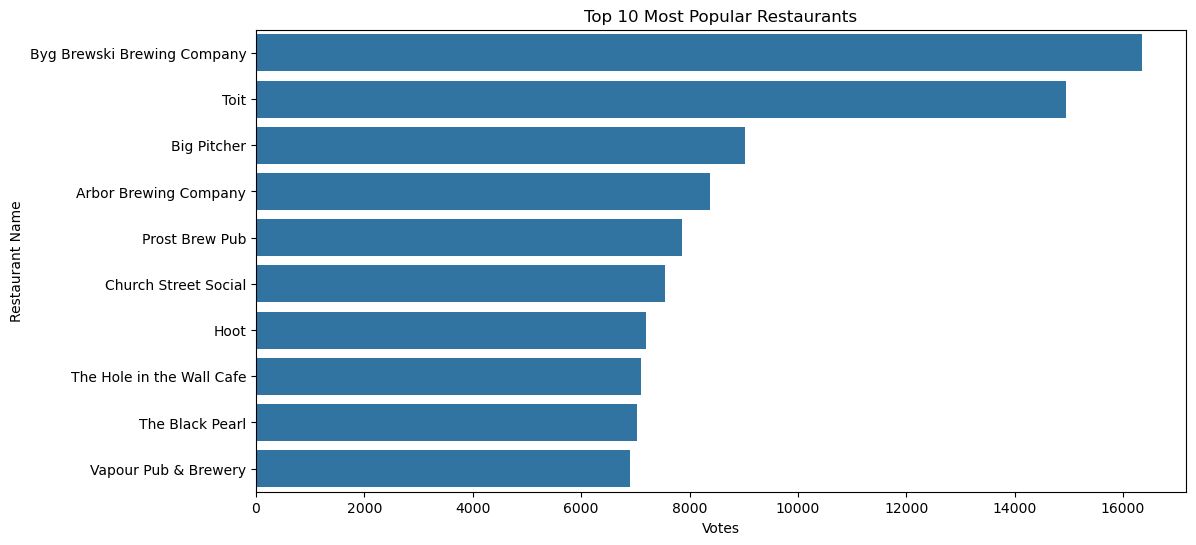

In [35]:
# Top restaurants based on votes

top_restaurants = df.sort_values(by='votes', ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_restaurants['votes'],
    y=top_restaurants['name']
)

plt.title("Top 10 Most Popular Restaurants")
plt.xlabel("Votes")
plt.ylabel("Restaurant Name")

plt.show()

# Step 20: Data Visualization


## WordCloud of Restaurant Features

In [36]:
# Install wordcloud if needed

!pip install wordcloud

In [38]:
import sys

!{sys.executable} -m pip install wordcloud

In [39]:
from wordcloud import WordCloud

In [40]:
# Combine all text

text = " ".join(df['combined_features'])

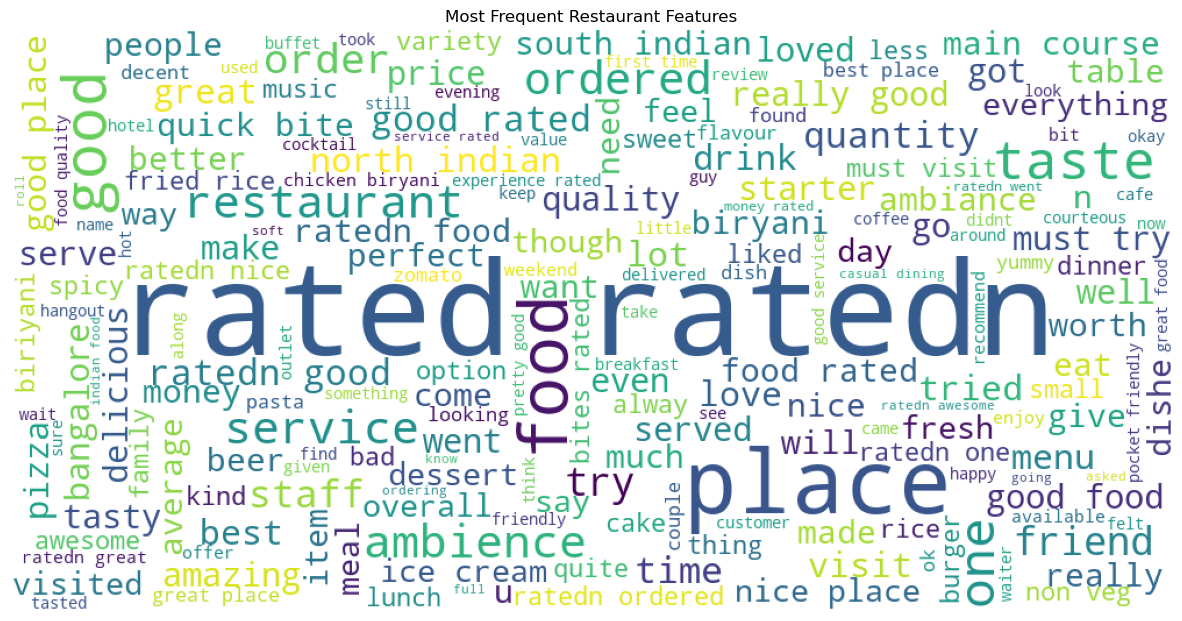

In [41]:
# Generate WordCloud

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Most Frequent Restaurant Features")

plt.show()

# Conclusion

In this project, a content-based restaurant recommendation system was successfully developed using the Zomato restaurant dataset.

The system recommends similar restaurants by analyzing important restaurant features such as:

- cuisines
- restaurant type
- dishes liked
- customer reviews

To build the recommendation engine, the following Natural Language Processing (NLP) techniques were used:

- Text preprocessing
- TF-IDF Vectorization
- Cosine Similarity

The recommendation system calculates similarity between restaurants and provides top restaurant suggestions sorted according to ratings.

In addition to recommendation generation, data visualization techniques such as WordCloud analysis were also implemented to identify the most frequent restaurant-related features and customer preferences present in the dataset.

This project demonstrates the practical implementation of:

- Recommendation Systems
- Natural Language Processing (NLP)
- Text Mining
- Data Visualization

in real-world applications.

The developed system can further be enhanced by integrating:

- collaborative filtering
- deep learning models
- user personalization
- real-time restaurant reviews

to create a more intelligent and scalable food recommendation platform.

# Step 21: Future Improvements



## Future Scope

The project can be improved further by:
- Adding collaborative filtering
- Deploying with Streamlit cloud
- Adding restaurant images
- Using deep learning recommendation models
- Integrating live Zomato APIs
- Adding location-based recommendations